Loading Keras model...
✅ Model loaded!
Processing image: C:\Users\deyko\Desktop\newdbrdidea\newtrainimg\2338_left.jpg
Generating explanation... (Be patient)


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05810570391314583..1.0141558839106388].


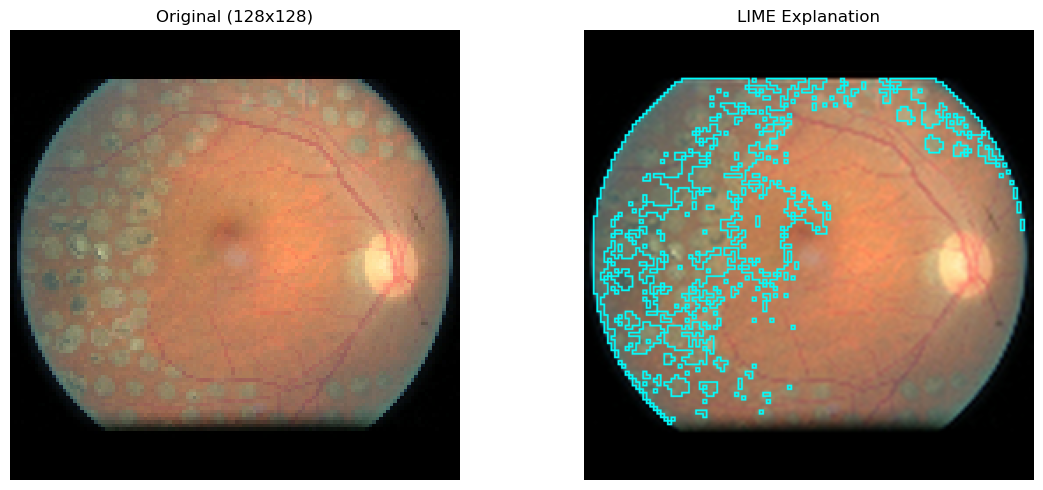

✅ Saved as 'lime_explanation.jpg'


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ==========================================
# 1. CONFIGURATION
# ==========================================
MODEL_PATH = r'C:\Users\deyko\Desktop\dbrd\best_model_final.h5'  # ✓ Correct path
IMAGE_PATH = r'C:\Users\deyko\Desktop\newdbrdidea\newtrainimg\2338_left.jpg'

TARGET_SIZE = (128, 128)  # Adjust based on your model's input size
CLASS_LABELS = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative"}

# ==========================================
# 2. LOAD KERAS MODEL (✓ Uses TensorFlow, not PyTorch)
# ==========================================
print("Loading Keras model...")
model = load_model(MODEL_PATH, compile=False)  # ✓ Works with .h5
print("✅ Model loaded!")

def predict_fn(images):
    images = images.astype('float32')
    images /= 255.0
    return model.predict(images, verbose=0)

# ==========================================
# 3. RUN LIME & VISUALIZE
# ==========================================
try:
    print(f"Processing image: {IMAGE_PATH}")
    img = image.load_img(IMAGE_PATH, target_size=TARGET_SIZE)
    img_array = image.img_to_array(img)
    
    explainer = lime_image.LimeImageExplainer()
    print("Generating explanation... (Be patient)")
    
    explanation = explainer.explain_instance(
        img_array.astype('double'),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    # Visualize
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original ({TARGET_SIZE[0]}x{TARGET_SIZE[1]})")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    marked_image = mark_boundaries(temp / 255.0, mask, color=(0, 1, 1), mode='subpixel')
    plt.imshow(marked_image)
    plt.title("LIME Explanation")
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("lime_explanation.jpg", dpi=150)
    plt.show()
    print("✅ Saved as 'lime_explanation.jpg'")
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()